In [48]:
from sklearn import datasets
import numpy as np
from pandas import DataFrame
digits = datasets.load_digits()
print(digits.images.shape)
print(digits.keys())

X = digits.data
y = digits.target[:,np.newaxis]

print(y.shape)



(1797, 8, 8)
dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
(1797, 1)


/Users/ibolde/.pyenv/versions/3.14.0/lib/python3.14/site-packages/sklearn/manifold/_isomap.py:360: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/Users/ibolde/.pyenv/versions/3.14.0/lib/python3.14/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


(1797, 40)


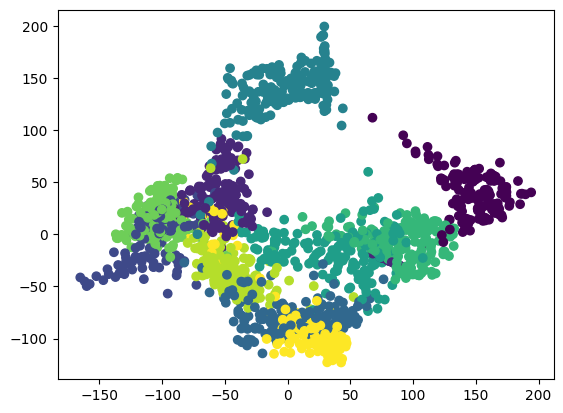

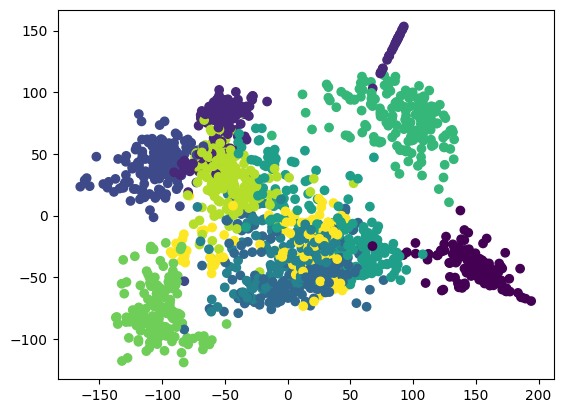

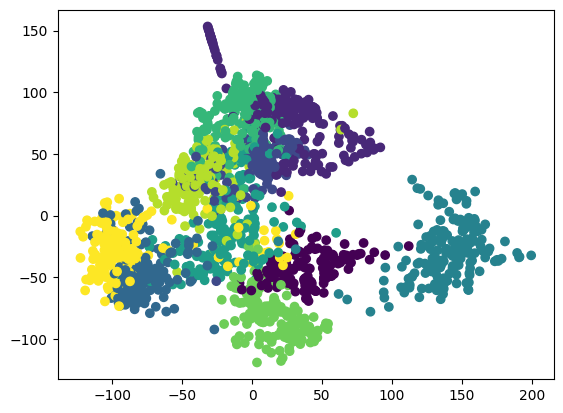

In [49]:
from sklearn.manifold import Isomap
import matplotlib.pyplot as plt
isomap = Isomap(n_components=40)

isomap.fit(X)

X_reduced = isomap.transform(X )

print(X_reduced.shape)

plt.scatter(X_reduced.T[0] , X_reduced.T[1] , c=y.T)
plt.show()
plt.scatter(X_reduced.T[0] , X_reduced.T[2] , c=y.T)
plt.show()
plt.scatter(X_reduced.T[1] , X_reduced.T[2] , c=y.T)
plt.show()

/Users/ibolde/.pyenv/versions/3.14.0/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/ibolde/.pyenv/versions/3.14.0/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


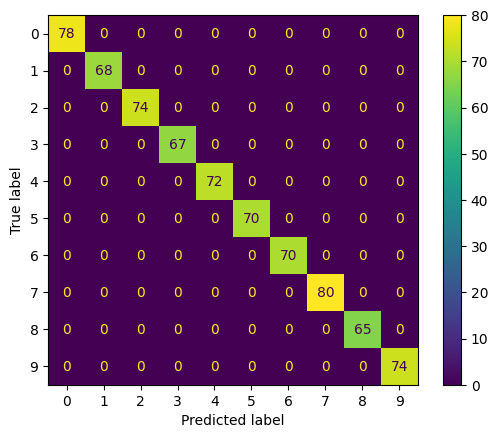

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X , y , test_size=0.6)

LR = LogisticRegression( solver="sag")
LR.fit( X_train , y_train)
y_pred = LR.predict(X_train)
im = ConfusionMatrixDisplay(confusion_matrix(y_pred , y_train))
im.plot()




AttributeError: 'LogisticRegression' object has no attribute 'accuracy_score'

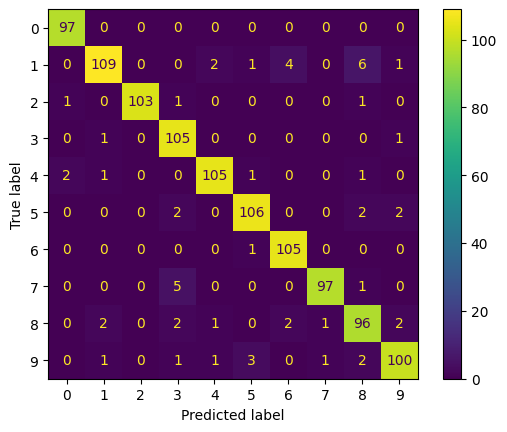

In [52]:
y_pred = LR.predict(X_test)
im = ConfusionMatrixDisplay(confusion_matrix(y_pred , y_test))
im.plot()

LR.score(X_test , y_test)

LR.accuracy_score()